# EDA: Сессионные рекомендации объявлений

**Ключевые колонки**:

| Колонка | Смысл |
|---|---|
| `x` | идентификатор контекста ранжирования |
| `buyer_user_id` | обезличенный идентификатор пользователя |
| `item_id` | идентификатор айтема |
| `title` | заголовок объявления |
| `image_link` | имя файла изображения |
| `float_1 … float_80` | числовые фичи модели |
| `cat_1, cat_2, cat_3` | категориальные фичи |
| `strong_target` | целевая метка релевантности |



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(60)


DATA_DIR = Path("../data")
SPLITS = {
    "train": DATA_DIR / "train.parquet",
    "val": DATA_DIR / "val.parquet",
    "test": DATA_DIR / "test.parquet",
}

lf = {name: pl.scan_parquet(path) for name, path in SPLITS.items()}
train = lf["train"]

In [2]:
schema = train.collect_schema()

float_cols = [c for c in schema.names() if c.startswith("float_")]
cat_cols = [c for c in schema.names() if c.startswith("cat_")]
id_cols = ["x", "buyer_user_id", "item_id"]
text_cols = ["title", "image_link"]
TARGET = "strong_target"

print(f"Всего колонок: {len(schema.names())}")
print(f"  ID-колонки:        {id_cols}")
print(f"  Текстовые:         {text_cols}")
print(f"  Категориальные:    {cat_cols}")
print(f"  Числовые (float):  {len(float_cols)} шт. ({float_cols[0]} … {float_cols[-1]})")
print(f"  Таргет:            {TARGET}")

# Типы колонок
pl.DataFrame(
    {"column": schema.names(), "dtype": [str(t) for t in schema.dtypes()]}
).head(12)

Всего колонок: 89
  ID-колонки:        ['x', 'buyer_user_id', 'item_id']
  Текстовые:         ['title', 'image_link']
  Категориальные:    ['cat_1', 'cat_2', 'cat_3']
  Числовые (float):  80 шт. (float_1 … float_80)
  Таргет:            strong_target


column,dtype
str,str
"""x""","""String"""
"""buyer_user_id""","""Int64"""
"""item_id""","""Int64"""
"""title""","""String"""
"""image_link""","""String"""
"""float_1""","""Float32"""
"""float_2""","""Float32"""
"""float_3""","""Float32"""
"""float_4""","""Float32"""


Смотрим размеры выборок, число групп ранжирования (`x`) и среднее число кандидатов на группу.

In [3]:
overview = (
    pl.concat(
        [
            lf[name]
            .select(
                pl.lit(name).alias("split"),
                pl.len().alias("rows"),
                pl.col("x").n_unique().alias("groups"),
                pl.col("buyer_user_id").n_unique().alias("users"),
                pl.col("item_id").n_unique().alias("items"),
            )
            for name in SPLITS
        ]
    )
    .with_columns((pl.col("rows") / pl.col("groups")).round(1).alias("cand_per_group"))
    .collect()
)
overview

split,rows,groups,users,items,cand_per_group
str,u32,u32,u32,u32,f64
"""train""",2795348,48617,45922,2109018,57.5
"""val""",73947,1345,1271,70973,55.0
"""test""",932617,14975,14209,860571,62.3


## Распределение таргета в сплитах

In [4]:
target_dist = (
    pl.concat(
        [
            lf[name]
            .group_by(TARGET)
            .len()
            .with_columns(pl.lit(name).alias("split"))
            for name in SPLITS
        ]
    )
    .collect()
    .with_columns(
        (pl.col("len") / pl.col("len").sum().over("split") * 100).round(3).alias("pct, %")
    )
    .sort("split", TARGET)
)
target_dist

strong_target,len,split,"pct, %"
i32,u32,str,f64
0,912625,"""test""",97.856
1,17503,"""test""",1.877
2,2057,"""test""",0.221
3,432,"""test""",0.046
0,2723034,"""train""",97.413
1,61016,"""train""",2.183
2,9802,"""train""",0.351
3,1496,"""train""",0.054
0,72042,"""val""",97.424


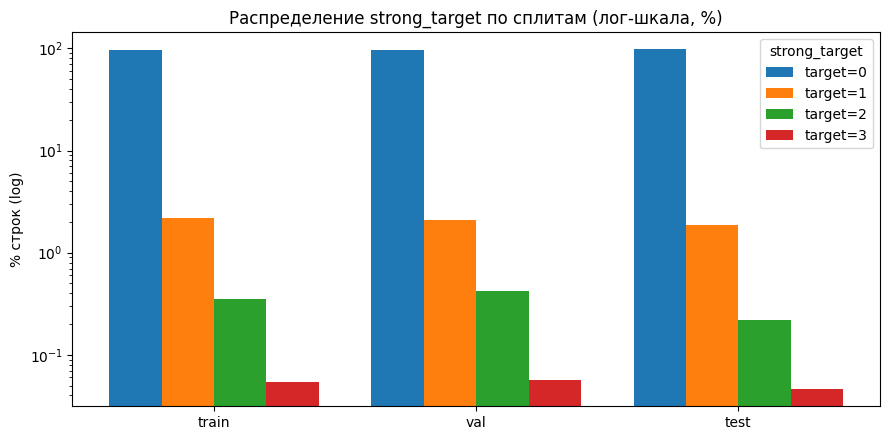

In [5]:
splits = list(SPLITS)
grades = sorted(target_dist[TARGET].unique().to_list())
width = 0.8 / len(grades)
x_pos = np.arange(len(splits))

plt.figure(figsize=(9, 4.5))
for i, g in enumerate(grades):
    pct = [
        target_dist.filter((pl.col("split") == s) & (pl.col(TARGET) == g))["pct, %"].sum()
        for s in splits
    ]
    plt.bar(x_pos + i * width, pct, width, label=f"target={g}")
plt.yscale("log")
plt.xticks(x_pos + width * (len(grades) - 1) / 2, splits)
plt.ylabel("% строк (log)")
plt.title("Распределение strong_target по сплитам (лог-шкала, %)")
plt.legend(title="strong_target")
plt.tight_layout()
plt.show()

## Структура групп ранжирования (`x`)

In [6]:
group_stats = (
    train.group_by("x")
    .agg(
        pl.len().alias("size"),
        (pl.col(TARGET) > 0).sum().alias("n_pos"),
    )
    .collect()
)
group_stats.head(5)

x,size,n_pos
str,u32,u32
"""18480c5a113de30365d5736026ad0a496edb""",77,1
"""d07132c5e4cfbed84615f65c00c0921cacb4""",74,1
"""c34e3f44d1ea0012e296fea1c3d1cd44d853""",31,1
"""4c2988444fe787727572c341191235b42beb""",31,1
"""c43c2dccee67f4babcdd48c13aed0e6a15bc""",31,1


In [7]:
print("Размер группы (число кандидатов):")
print(group_stats["size"].describe())
print("\nЧисло позитивов (target>0) в группе:")
print(group_stats["n_pos"].describe())
print(f"\nГрупп без единого позитива: {(group_stats['n_pos'] == 0).sum()} из {group_stats.height}")

Размер группы (число кандидатов):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 48617.0   │
│ null_count ┆ 0.0       │
│ mean       ┆ 57.497336 │
│ std        ┆ 29.822286 │
│ min        ┆ 2.0       │
│ 25%        ┆ 31.0      │
│ 50%        ┆ 41.0      │
│ 75%        ┆ 97.0      │
│ max        ┆ 101.0     │
└────────────┴───────────┘

Число позитивов (target>0) в группе:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 48617.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 1.487422 │
│ std        ┆ 1.212563 │
│ min        ┆ 1.0      │
│ 25%        ┆ 1.0      │
│ 50%        ┆ 1.0      │
│ 75%        ┆ 2.0      │
│ max        ┆ 46.0     │
└────────────┴──────────┘

Групп без единого позитива: 0 из 48617


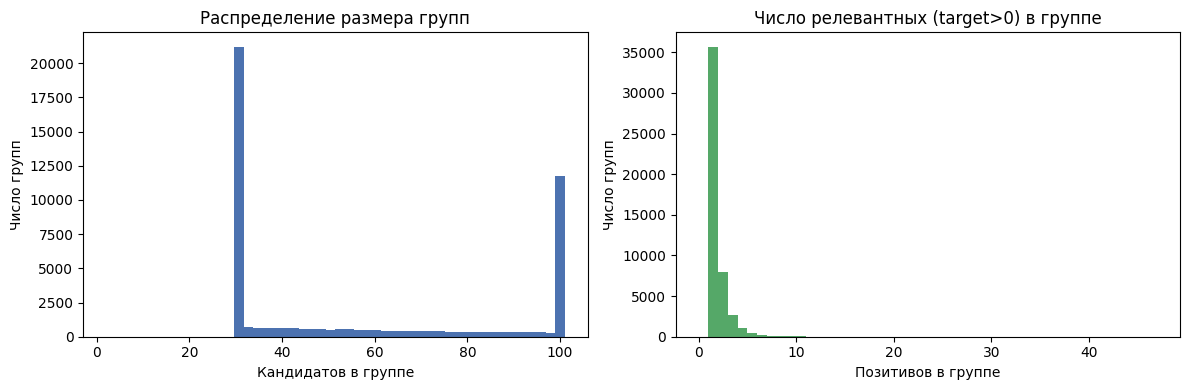

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(group_stats["size"], bins=50, color="#4C72B0")
axes[0].set_title("Распределение размера групп")
axes[0].set_xlabel("Кандидатов в группе")
axes[0].set_ylabel("Число групп")

axes[1].hist(group_stats["n_pos"], bins=range(0, int(group_stats["n_pos"].max()) + 2), color="#55A868")
axes[1].set_title("Число релевантных (target>0) в группе")
axes[1].set_xlabel("Позитивов в группе")
axes[1].set_ylabel("Число групп")
plt.tight_layout()
plt.show()

## Категориальные признаки (`cat_1`, `cat_2`, `cat_3`)


In [9]:
print("Кол-во уникальных значений: ")
for c in cat_cols:
    print(f"  {c}: {train.select(pl.col(c).n_unique()).collect().item()} уникальных значений")

Кол-во уникальных значений: 
  cat_1: 5 уникальных значений
  cat_2: 2 уникальных значений
  cat_3: 52 уникальных значений


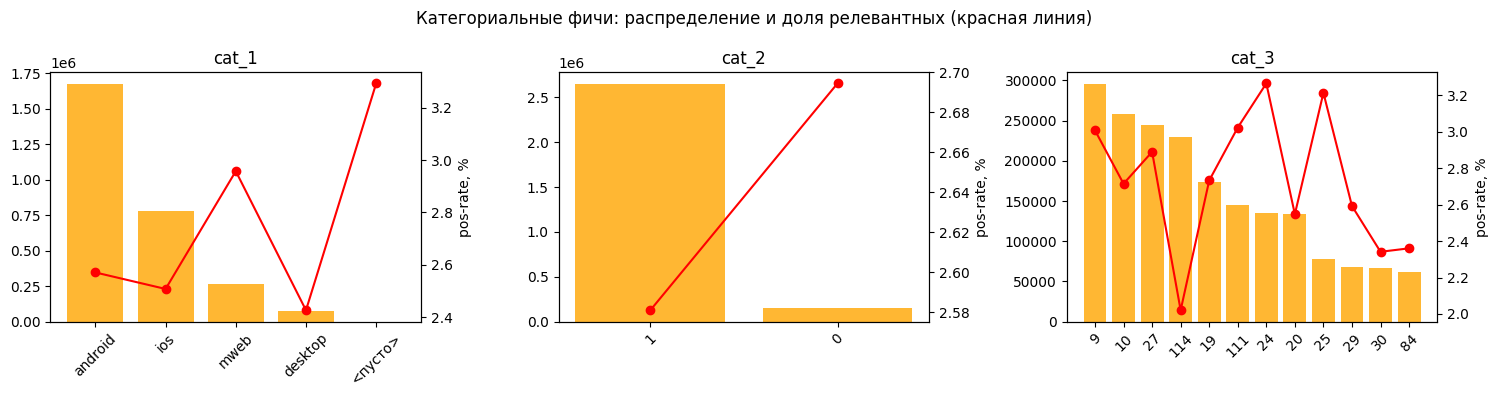

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, cat_cols):
    agg = (
        train
        .group_by(c)
        .agg(
            pl.len().alias("rows"),
            (pl.col(TARGET) > 0).mean().alias("pos_rate"),
        )
        .sort("rows", descending=True)
        .head(12)
        .collect()
    )
    labels = [s if s != "" else "<пусто>" for s in agg[c].to_list()]
    ax.bar(labels, agg["rows"], color="orange", alpha=0.8, label="строк")
    ax.set_title(f"{c}")
    ax.tick_params(axis="x", rotation=45)

    ax2 = ax.twinx()
    ax2.plot(labels, agg["pos_rate"] * 100, color="red", marker="o", label="pos-rate, %")
    ax2.set_ylabel("pos-rate, %")
    # ax2.grid(True)
fig.suptitle("Категориальные фичи: распределение и доля релевантных (красная линия)")
plt.tight_layout()
plt.show()

## Числовые признаки (`float_1 … float_80`)


In [11]:
n_rows = overview.filter(pl.col("split") == "train")["rows"].item()
null_counts = train.select([pl.col(c).null_count().alias(c) for c in float_cols]).collect()
null_counts

float_1,float_2,float_3,float_4,float_5,float_6,float_7,float_8,float_9,float_10,float_11,float_12,float_13,float_14,float_15,float_16,float_17,float_18,float_19,float_20,float_21,float_22,float_23,float_24,float_25,float_26,float_27,float_28,float_29,float_30,float_31,float_32,float_33,float_34,float_35,float_36,float_37,…,float_44,float_45,float_46,float_47,float_48,float_49,float_50,float_51,float_52,float_53,float_54,float_55,float_56,float_57,float_58,float_59,float_60,float_61,float_62,float_63,float_64,float_65,float_66,float_67,float_68,float_69,float_70,float_71,float_72,float_73,float_74,float_75,float_76,float_77,float_78,float_79,float_80
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
38934,0,0,208365,0,38934,75518,0,1590207,0,0,0,187418,0,84500,50412,0,42792,0,264568,45788,37231,2367645,84500,1143271,34798,208365,84500,38934,38934,0,0,1948554,187418,0,275280,50412,…,0,38934,0,0,0,1933343,0,275280,187418,0,0,0,1143271,2367645,84500,0,0,75518,0,0,0,1590207,50412,1322816,1933343,0,247515,34798,42041,0,0,75518,0,0,0,38934,0


In [12]:
null_df = (
    pl.DataFrame(
        {
            "feature": float_cols,
            "null_pct": [round(100 * null_counts[c].item() / n_rows, 1) for c in float_cols],
        }
    )
    .sort("null_pct", descending=True)
)
print(f"Фичей без пропусков: {(null_df['null_pct'] == 0).sum()} из {len(float_cols)}")
print("Топ-15 по доле пропусков:")
null_df.head(15)

Фичей без пропусков: 34 из 80
Топ-15 по доле пропусков:


feature,null_pct
str,f64
"""float_23""",84.7
"""float_57""",84.7
"""float_33""",69.7
"""float_39""",69.7
"""float_40""",69.7
"""float_49""",69.2
"""float_68""",69.2
"""float_9""",56.9
"""float_65""",56.9


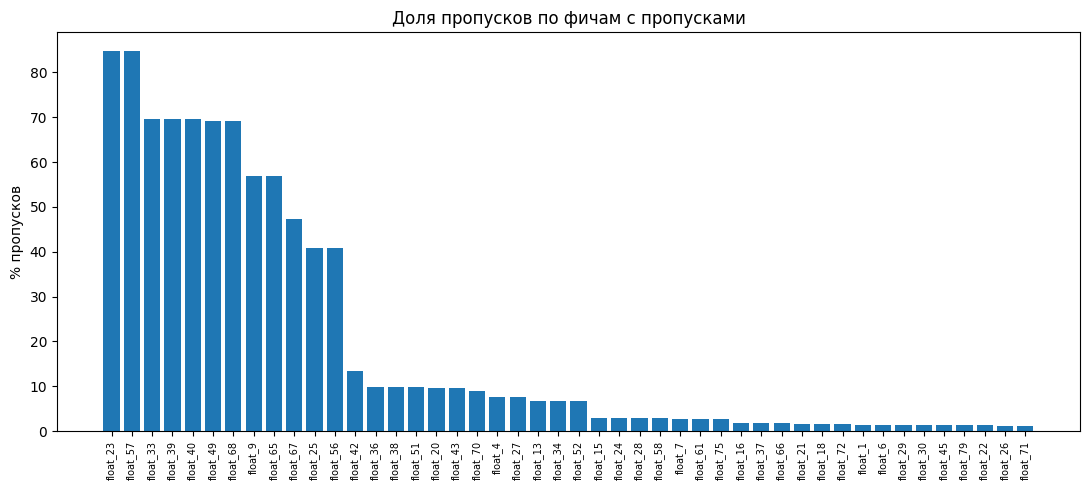

In [13]:
with_nulls = null_df.filter(pl.col("null_pct") > 0)
plt.figure(figsize=(11, 5))
plt.bar(with_nulls["feature"], with_nulls["null_pct"])
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("% пропусков")
plt.title(f"Доля пропусков по фичам с пропусками")
plt.tight_layout()
plt.show()

### Базовые статистики по всем float-фичам

In [14]:
stat_exprs = []
for c in float_cols:
    stat_exprs += [
        pl.col(c).mean().alias(f"{c}__mean"),
        pl.col(c).std().alias(f"{c}__std"),
        pl.col(c).min().alias(f"{c}__min"),
        pl.col(c).quantile(0.5).alias(f"{c}__median"),
        pl.col(c).max().alias(f"{c}__max"),
    ]
stats_row = train.select(stat_exprs).collect().to_dicts()[0]
stats = pl.DataFrame(
    {
        "feature": float_cols,
        "mean": [stats_row[f"{c}__mean"] for c in float_cols],
        "std": [stats_row[f"{c}__std"] for c in float_cols],
        "min": [stats_row[f"{c}__min"] for c in float_cols],
        "median": [stats_row[f"{c}__median"] for c in float_cols],
        "max": [stats_row[f"{c}__max"] for c in float_cols],
    }
)
stats.head(1)

feature,mean,std,min,median,max
str,f64,f64,f64,f64,f64
"""float_1""",0.013447,0.695171,0.0,0.004826,827.026367


### Разброс масштабов фичей (по std):

In [15]:
stats.sort("std", descending=True).head(10)

feature,mean,std,min,median,max
str,f64,f64,f64,f64,f64
"""float_21""",3.8930e6,2.9346e9,0.0,6000.0,4.6875e12
"""float_62""",2491.152344,3041274.5,-1.0,0.846154,5.0000e9
"""float_60""",1853.320923,2099370.5,-1.0,0.69,3.5000e9
"""float_5""",1091.782227,780685.125,-1.0,0.83022,9.0909088e8
"""float_17""",336.019104,283508.3125,-1.0,0.666667,3.99965568e8
"""float_55""",154.277237,120861.0625,-1.0,0.23,1.63042208e8
"""float_67""",64625.070312,47157.34375,-114395.0,57979.0,406264.0
"""float_41""",178.667831,42535.222656,-1.0,0.254545,4.2e7
"""float_28""",58.805206,7697.930664,0.0,18.420904,7.714485e6


### Фичи с наименьшим разбросом:

In [16]:
stats.sort("std").head(5)

feature,mean,std,min,median,max
str,f64,f64,f64,f64,f64
"""float_4""",0.006879,0.011348,-0.05,0.002326,0.070353
"""float_26""",0.014712,0.017103,0.0,0.008296,2.757734
"""float_42""",0.849425,0.11826,-0.253379,0.877866,1.0
"""float_70""",0.808942,0.133452,-0.284439,0.834912,1.0
"""float_59""",0.053382,0.185771,0.0,0.0,1.0


### Грубая оценка важности вещественных фичей

In [17]:
# |diff| = |mean(target>0) - mean(target==0)| / std(all)
rel = pl.col(TARGET) > 0
sig_exprs = []
for c in float_cols:
    sig_exprs += [
        pl.col(c).filter(rel).mean().alias(f"{c}__pos"),
        pl.col(c).filter(~rel).mean().alias(f"{c}__neg"),
        pl.col(c).std().alias(f"{c}__std"),
    ]
sig_row = train.select(sig_exprs).collect().to_dicts()[0]

signal = (
    pl.DataFrame(
        {
            "feature": float_cols,
            "mean_pos": [sig_row[f"{c}__pos"] for c in float_cols],
            "mean_neg": [sig_row[f"{c}__neg"] for c in float_cols],
            "std": [sig_row[f"{c}__std"] for c in float_cols],
        }
    )
    .with_columns(
        (
            (pl.col("mean_pos") - pl.col("mean_neg")).abs()
            / pl.when(pl.col("std") > 0).then(pl.col("std")).otherwise(None)
        ).alias("std_mean_diff")
    )
    .sort("std_mean_diff", descending=True, nulls_last=True)
)
top_signal = signal.head(15)
print("Топ-15 фичей по сигналу к релевантности:")
top_signal.select("feature", "mean_pos", "mean_neg", "std_mean_diff")



Топ-15 фичей по сигналу к релевантности:


feature,mean_pos,mean_neg,std_mean_diff
str,f64,f64,f64
"""float_73""",0.42413,0.29439,0.398569
"""float_31""",3.774954,3.144353,0.324676
"""float_46""",8.808405,7.114094,0.319993
"""float_11""",21.823973,17.56884,0.290851
"""float_65""",0.8539,0.627808,0.23943
"""float_77""",34.683643,22.666916,0.221804
"""float_67""",74122.28125,64354.757812,0.207126
"""float_44""",0.252575,0.19299,0.200143
"""float_68""",11.079145,12.601657,0.198012


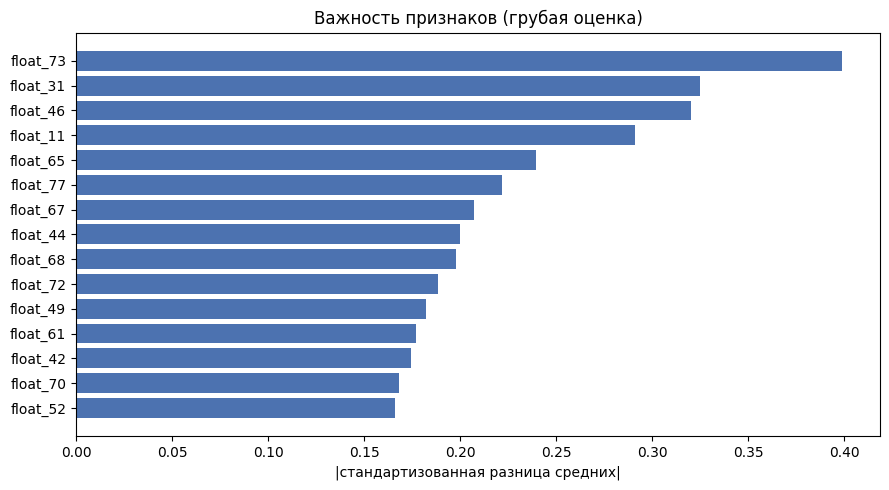

In [18]:
plt.figure(figsize=(9, 5))
plt.barh(top_signal["feature"].to_list()[::-1], top_signal["std_mean_diff"].to_list()[::-1], color="#4C72B0")
plt.xlabel("|стандартизованная разница средних|")
plt.title("Важность признаков (грубая оценка)")
plt.tight_layout()
plt.show()

### Распределения топ фичей для релевантных и нерелевантных объявлений

In [19]:
top_feats = top_signal["feature"].to_list()[:6]
sample = (
    train.select(top_feats + [TARGET])
    .collect()
    .with_columns((pl.col(TARGET) > 0).alias("relevant"))
)
sample.head()

float_73,float_31,float_46,float_11,float_65,float_77,strong_target,relevant
f32,f32,f32,f32,f32,f32,i32,bool
0.34829,3.0,6.0,4.640361,0.220457,0.729862,0,false
0.107527,3.0,7.0,17.783461,null,3.242253,0,false
0.0038,0.0,0.0,5.369921,0.013892,0.0,0,false
1.1602e-9,0.0,0.0,6.288498,null,0.0,0,false
0.979884,5.0,10.0,10.445508,null,39.460072,0,false


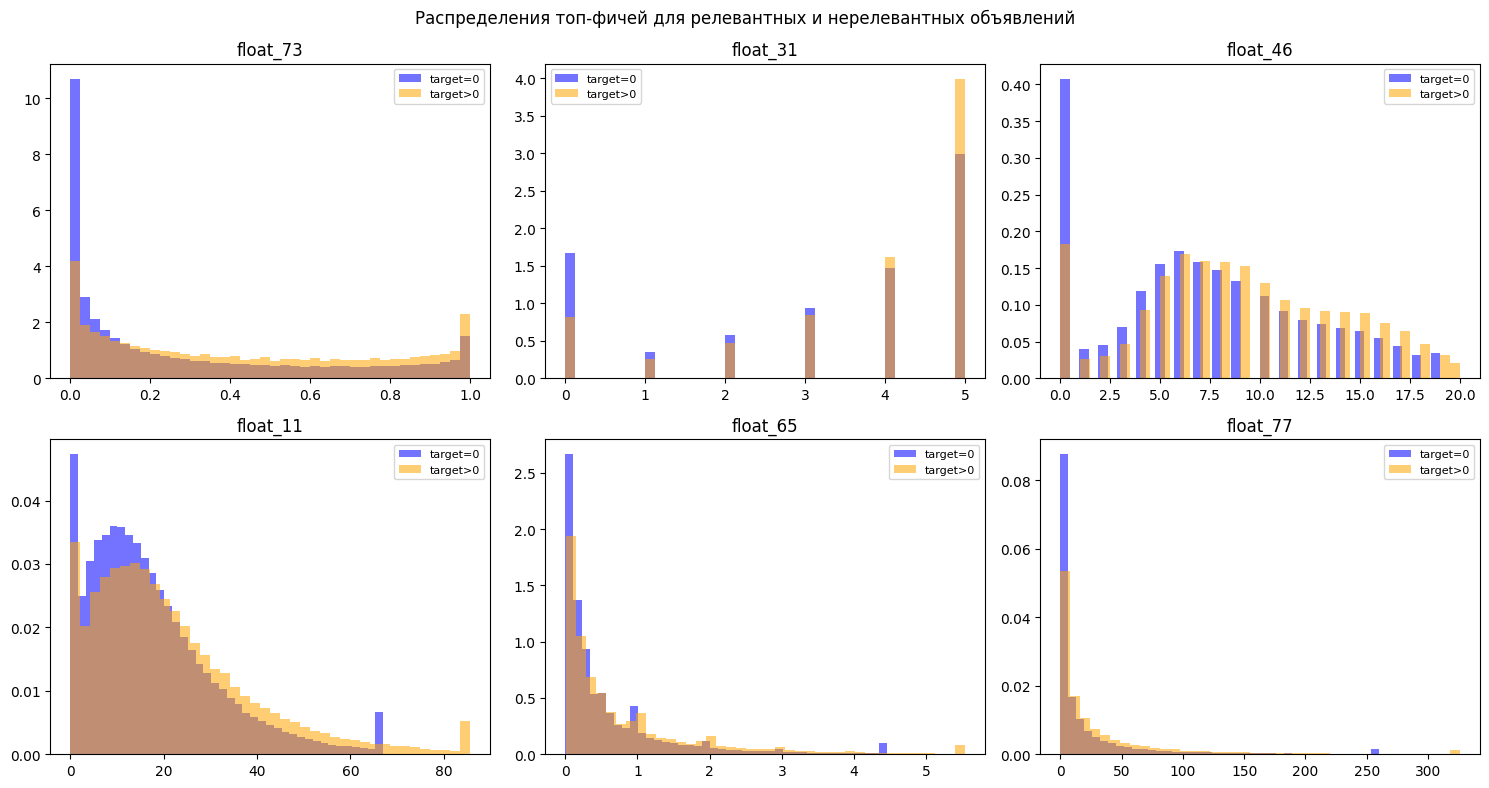

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), top_feats):
    for is_rel, color, lab in [(False, "blue", "target=0"), (True, "orange", "target>0")]:
        vals = sample.filter(pl.col("relevant") == is_rel)[c].drop_nulls()
        if len(vals) == 0:
            continue
        # Обрезаем значения 1 и 99 перцентилем
        lo, hi = np.nanpercentile(vals, [1, 99])
        clipped = np.clip(vals, lo, hi)
        ax.hist(clipped, bins=40, density=True, alpha=0.55, color=color, label=lab)
    ax.set_title(c)
    ax.legend(fontsize=8)
fig.suptitle("Распределения топ-фичей для релевантных и нерелевантных объявлений")
plt.tight_layout()
plt.show()

## Заголовки (`title`)


In [21]:
print(f"Пустых заголовков: {train.select((pl.col("title").str.strip_chars() == "").sum()).collect().item()}")
print(f"Уникальных заголовков: {train.select(pl.col("title").n_unique()).collect().item():,}")

title_stats = train.select(
    pl.col("title").str.strip_chars().str.len_chars().alias("len_chars"),
    pl.col("title").str.split(" ").list.len().alias("n_words"),
).collect()
print("\nДлина заголовка (символы):")
title_stats.select("len_chars").describe()

Пустых заголовков: 0
Уникальных заголовков: 1,370,020

Длина заголовка (символы):


statistic,len_chars
str,f64
"""count""",2.795348e6
"""null_count""",0.0
"""mean""",29.52508
"""std""",10.898758
"""min""",1.0
"""25%""",22.0
"""50%""",30.0
"""75%""",38.0
"""max""",100.0


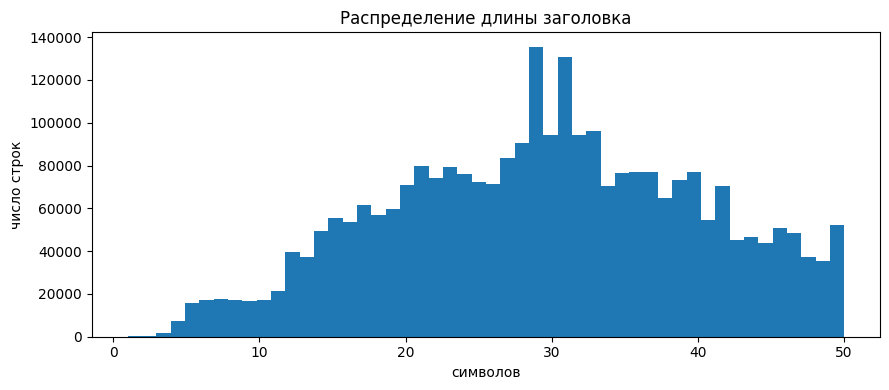

In [22]:
plt.figure(figsize=(9, 4))
lens = title_stats["len_chars"].drop_nulls()
plt.hist(np.clip(lens, 0, np.percentile(lens, 99)), bins=50)
plt.title("Распределение длины заголовка")
plt.xlabel("символов")
plt.ylabel("число строк")
plt.tight_layout()
plt.show()

In [23]:
# Несколько примеров заголовков релевантных айтемов
print("\nПримеры заголовков с разной релевантностью:")
print(
    train.filter(pl.col(TARGET) >= 2)
    .select("title", TARGET)
    .head(5)
    .collect()
)


Примеры заголовков с разной релевантностью:
shape: (5, 2)
┌──────────────────────────────────────────┬───────────────┐
│ title                                    ┆ strong_target │
│ ---                                      ┆ ---           │
│ str                                      ┆ i32           │
╞══════════════════════════════════════════╪═══════════════╡
│ Racer RC50QT-9 Lupus, 2015, 19 000 км    ┆ 2             │
│ Продам колеса                            ┆ 2             │
│ Omaks Motors Classic 150, 2016, 7 000 км ┆ 2             │
│ Покрышка 20 bmx                          ┆ 3             │
│ Модель на мужскую стрижку                ┆ 2             │
└──────────────────────────────────────────┴───────────────┘
